In [4]:
# import libraries
import tensorflow as tf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

ModuleNotFoundError: No module named 'tensorflow'

In [ ]:
# load dataset
df=pd.read_csv("weatherAUS.csv")
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Humidity9am,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,71.0,22.0,1007.7,1007.1,8.0,NaN,16.9,21.8,No,No
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,44.0,25.0,1010.6,1007.8,NaN,NaN,17.2,24.3,No,No
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,38.0,30.0,1007.6,1008.7,NaN,2.0,21.0,23.2,No,No
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,45.0,16.0,1017.6,1012.8,NaN,NaN,18.1,26.5,No,No
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,82.0,33.0,1010.8,1006.0,7.0,8.0,17.8,29.7,No,No


In [ ]:
# handling date
df['Date']=pd.to_datetime(df['Date'])
df['year']=df['Date'].dt.year
df['month']=df['Date'].dt.month
df['day_of_week']=df['Date'].dt.dayofweek

# handle month and day with cyclic encoding

df["month_sin"] = np.sin(2 * np.pi * df["month"] / 12)
df["month_cos"] = np.cos(2 * np.pi * df["month"] / 12)

df["dow_sin"] = np.sin(2 * np.pi * df["day_of_week"] / 7)
df["dow_cos"] = np.cos(2 * np.pi * df["day_of_week"] / 7)
df.drop(["month", "day_of_week"], axis=1, inplace=True)
df.head()

,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,WindDir9am,...,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,year,month_sin,month_cos,dow_sin,dow_cos
0,2008-12-01,Albury,13.4,22.9,0.6,NaN,NaN,W,44.0,W,...,NaN,16.9,21.8,No,No,2008,-2.449294e-16,1.0,0.000000,1.000000
1,2008-12-02,Albury,7.4,25.1,0.0,NaN,NaN,WNW,44.0,NNW,...,NaN,17.2,24.3,No,No,2008,-2.449294e-16,1.0,0.781831,0.623490
2,2008-12-03,Albury,12.9,25.7,0.0,NaN,NaN,WSW,46.0,W,...,2.0,21.0,23.2,No,No,2008,-2.449294e-16,1.0,0.974928,-0.222521
3,2008-12-04,Albury,9.2,28.0,0.0,NaN,NaN,NE,24.0,SE,...,NaN,18.1,26.5,No,No,2008,-2.449294e-16,1.0,0.433884,-0.900969
4,2008-12-05,Albury,17.5,32.3,1.0,NaN,NaN,W,41.0,ENE,...,8.0,17.8,29.7,No,No,2008,-2.449294e-16,1.0,-0.433884,-0.900969


In [ ]:
# handle missing values
df.isnull().sum()
df.info()
# handle categorical columns missing values
for col in cat_columns:
    df[col] = df[col].fillna(df[col].mode()[0])

# handle numerical columns missing values
num_columns = df.select_dtypes(exclude='object').columns.tolist()

# fill missing values
df[cat_columns] = df[cat_columns].fillna(df[cat_columns].mode())
df[num_columns] = df[num_columns].fillna(df[num_columns].mean())
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145460 entries, 0 to 145459
Data columns (total 28 columns):
 #   Column         Non-Null Count   Dtype         
---  ------         --------------   -----         
 0   Date           145460 non-null  datetime64[ns]
 1   Location       145460 non-null  object        
 2   MinTemp        143975 non-null  float64       
 3   MaxTemp        144199 non-null  float64       
 4   Rainfall       142199 non-null  float64       
 5   Evaporation    82670 non-null   float64       
 6   Sunshine       75625 non-null   float64       
 7   WindGustDir    135134 non-null  object        
 8   WindGustSpeed  135197 non-null  float64       
 9   WindDir9am     134894 non-null  object        
 10  WindDir3pm     141232 non-null  object        
 11  WindSpeed9am   143693 non-null  float64       
 12  WindSpeed3pm   142398 non-null  float64       
 13  Humidity9am    142806 non-null  float64       
 14  Humidity3pm    140953 non-null  float64       
 15  

,0
Date,0
Location,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
Sunshine,0
WindGustDir,0
WindGustSpeed,0
WindDir9am,0


In [ ]:
# handle cat columns ()
# LabelEncoding
from sklearn.preprocessing import LabelEncoder
le=LabelEncoder()

df['RainToday']=le.fit_transform(df['RainToday'])
df['RainTomorrow']=le.fit_transform(df['RainTomorrow'])

# one-hot encoding
df = pd.get_dummies(
    df,
    columns=['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm'],
    drop_first=True
)
df.head()
df.shape


(145460, 117)

In [ ]:
# divide data into features and target
X=df.drop(['RainTomorrow', 'Date'],axis=1)
y=df['RainTomorrow']
X.head()
df.isnull().sum()

,0
Date,0
MinTemp,0
MaxTemp,0
Rainfall,0
Evaporation,0
...,...
WindDir3pm_SSW,0
WindDir3pm_SW,0
WindDir3pm_W,0
WindDir3pm_WNW,0


In [ ]:
# divide data into train test
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

# scaling data
from sklearn.preprocessing import StandardScaler
scaler=StandardScaler()
X_train=scaler.fit_transform(X_train)
X_test=scaler.transform(X_test)


In [ ]:
# import libraries for ANN
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense,Dropout
from tensorflow.keras.optimizers import Adam


In [ ]:
#Early stopping
early_stopping = tf.keras.callbacks.EarlyStopping(
    min_delta=0.001, # minimium amount of change to count as an improvement
    patience=20, # how many epochs to wait before stopping
    restore_best_weights=True,
)

# Initialising the model
model = Sequential()



In [ ]:
# define layers
model.add(Dense(64, activation='relu', input_shape=(115,)))
model.add(Dropout(0.25))
model.add(Dense(32, activation='relu'))
model.add(Dropout(0.2))
model.add(Dense(1, activation='sigmoid'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
# compile model
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
model_history = model.fit(X_train, y_train, batch_size = 32, epochs = 100, callbacks=early_stopping, validation_split=0.33)

Epoch 1/100
2437/2437 ━━━━━━━━━━━━━━━━━━━━ 17s 5ms/step - accuracy: 0.8348 - loss: 0.3821 - val_accuracy: 0.8495 - val_loss: 0.3482
Epoch 2/100
2437/2437 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8501 - loss: 0.3481 - val_accuracy: 0.8547 - val_loss: 0.3400
Epoch 3/100
2437/2437 ━━━━━━━━━━━━━━━━━━━━ 23s 9ms/step - accuracy: 0.8554 - loss: 0.3381 - val_accuracy: 0.8555 - val_loss: 0.3367
Epoch 4/100
2437/2437 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8577 - loss: 0.3332 - val_accuracy: 0.8570 - val_loss: 0.3334
Epoch 5/100
2437/2437 ━━━━━━━━━━━━━━━━━━━━ 8s 3ms/step - accuracy: 0.8601 - loss: 0.3291 - val_accuracy: 0.8580 - val_loss: 0.3305
Epoch 6/100
2437/2437 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8604 - loss: 0.3266 - val_accuracy: 0.8580 - val_loss: 0.3309
Epoch 7/100
2437/2437 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8614 - loss: 0.3241 - val_accuracy: 0.8577 - val_loss: 0.3298
Epoch 8/100
2437/2437 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8623 - loss

In [ ]:
# predict and evaluate test set results
y_pred=model.predict(X_test)
y_pred=(y_pred>=0.5)

910/910 ━━━━━━━━━━━━━━━━━━━━ 4s 5ms/step


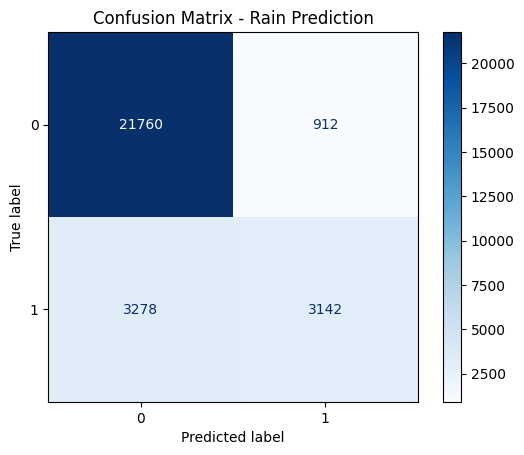

In [ ]:
# visualize confusion matrix using direct confusion matrix not seaborn
from sklearn.metrics import ConfusionMatrixDisplay,classification_report

ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred, cmap="Blues"
)
plt.title("Confusion Matrix - Rain Prediction")
plt.show()

In [ ]:
from sklearn.metrics import classification_report
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.87      0.96      0.91     22672
           1       0.78      0.49      0.60      6420

    accuracy                           0.86     29092
   macro avg       0.82      0.72      0.76     29092
weighted avg       0.85      0.86      0.84     29092



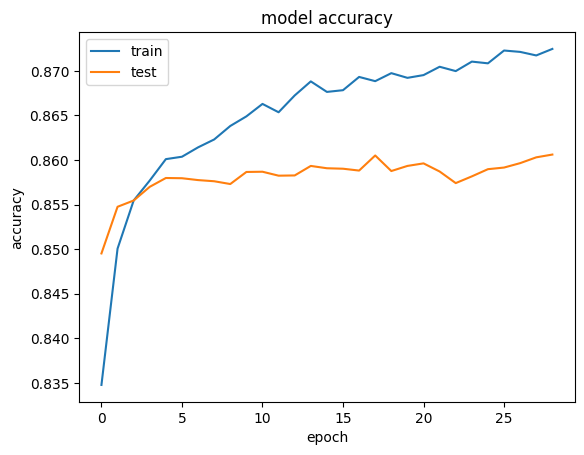

In [ ]:
# summarize history from model
plt.plot(model_history.history['accuracy'])
plt.plot(model_history.history['val_accuracy'])
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.legend(['train','test'],loc='best')
plt.title('model accuracy')
plt.show()

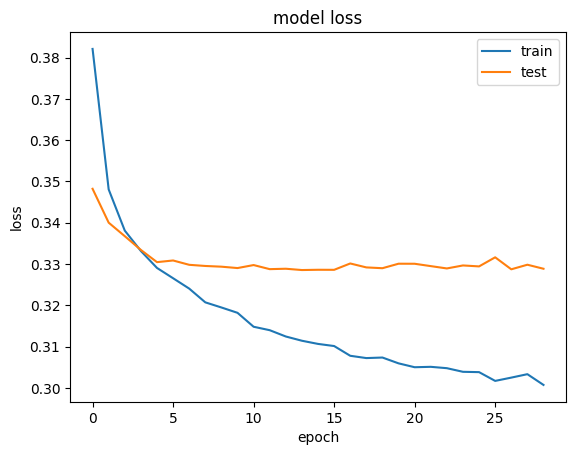

In [ ]:
# summarize history for loss
plt.plot(model_history.history['loss'])
plt.plot(model_history.history['val_loss'])
plt.xlabel('epoch')
plt.ylabel('loss')
plt.title('model loss')
plt.legend(['train','test'],loc='best')
plt.show()

In [ ]:
# calculate the accuracy
from sklearn.metrics import accuracy_score
score=accuracy_score(y_test,y_pred)
score

0.8559741509693386